---
date: "2026-09-07"
date-modified: last-modified
format:
  html:
    toc: true
---



# Problem Set: Maximum Likelihood Estimation

This problem set focuses on parameter estimation via [Maximum Likelihood Estimation](maximum-likelihood-estimation.ipynb) (MLE). We investigate constructing likelihood and log-likelihood functions, finding critical points via first-order conditions, rigorously confirming global maxima via second-order conditions, and interpreting the resulting estimators.


## Problem 1: Maximum Likelihood Estimator for a Bernoulli Sample

**Problem Statement:**

Let $X_1, X_2, \dots, X_n$ be an [independent and identically distributed](independence-of-rvs.ipynb) (i.i.d.) [random sample](statistical-inference.ipynb#random-sample) from a [Bernoulli distribution](bernoulli-and-binomial-distributions.ipynb) with unknown success probability parameter $p \in (0, 1)$, such that each $X_i \sim \text{Bern}(p)$. Let $(x_1, x_2, \dots, x_n)$ denote the observed realizations, where each $x_i \in \{0, 1\}$.

Equivalently, one may consider the total number of successes $Y = \sum_{i=1}^n X_i$, which follows a [Binomial distribution](bernoulli-and-binomial-distributions.ipynb) $Y \sim \text{Bin}(n, p)$ with observed value $k = \sum_{i=1}^n x_i$.

**Part (a):** Write down the [Probability Mass Function](probability-mass-function.ipynb) (PMF) for a single Bernoulli trial, and construct the joint likelihood function $L(p)$ and the [log-likelihood function](maximum-likelihood-estimation.ipynb#def-log-likelihood) $l(p) = \ln L(p)$ for the sample.

**Part (b):** Derive the first-order condition $\frac{\partial l}{\partial p} = 0$ to find the candidate maximum likelihood estimator $\hat{p}$.

**Part (c):** Check the second-order condition $\frac{\partial^2 l}{\partial p^2}$ to confirm that $\hat{p}$ is a global maximum.

**Part (d):** Verify whether the resulting estimator $\hat{p}$ is [unbiased](statistical-inference.ipynb#def-unbiasedness) for $p$.

::: {.callout-tip collapse="true"}
## Solution

**Part (a): Likelihood and Log-Likelihood Functions**

A Bernoulli random variable $X_i \sim \text{Bern}(p)$ has the [probability mass function](probability-mass-function.ipynb):

$$
p_X(x) = p^x (1 - p)^{1 - x}, \quad x \in \{0, 1\}
$$

Because the observations $X_1, \dots, X_n$ are [independent](independence-of-rvs.ipynb) and identically distributed, the joint probability (the likelihood function $L(p)$) of observing the specific data realization $(x_1, \dots, x_n)$ is the product of their individual probabilities:

$$
L(p) = \prod_{i=1}^n p_X(x_i) = \prod_{i=1}^n p^{x_i} (1 - p)^{1 - x_i}
$$

To estimate the parameter $p$, we work with the [log-likelihood function](maximum-likelihood-estimation.ipynb#def-log-likelihood) $l(p) = \ln L(p)$, which converts the product into an algebraically tractable sum:

$$
\begin{aligned}
l(p) &= \ln \left( \prod_{i=1}^n p^{x_i} (1 - p)^{1 - x_i} \right) \\
&= \sum_{i=1}^n \ln \left( p^{x_i} (1 - p)^{1 - x_i} \right) \\
&= \sum_{i=1}^n \left[ x_i \ln(p) + (1 - x_i) \ln(1 - p) \right]
\end{aligned}
$$

---

**Part (b): First-Order Condition (FOC)**

The maximum likelihood estimator $\hat{p}$ maximizes $l(p)$ over the parameter space $p \in (0, 1)$:

$$
\hat{p} = \arg\max_{p \in (0, 1)} l(p)
$$

We check the first-order condition by computing the derivative with respect to $p$:

$$
\begin{aligned}
\frac{\partial l}{\partial p} &= \sum_{i=1}^n \left[ \frac{\partial}{\partial p} \big( x_i \ln(p) \big) + \frac{\partial}{\partial p} \big( (1 - x_i) \ln(1 - p) \big) \right] \\
&= \sum_{i=1}^n \left[ \frac{x_i}{p} + (1 - x_i) \cdot \frac{-1}{1 - p} \right] \\
&= \sum_{i=1}^n \left[ \frac{x_i}{p} + (x_i - 1) \left( \frac{1}{1 - p} \right) \right]
\end{aligned}
$$

Placing both terms over the common denominator $p(1 - p)$:

$$
\begin{aligned}
\frac{\partial l}{\partial p} &= \sum_{i=1}^n \left[ \frac{x_i (1 - p)}{p(1 - p)} + \frac{p(x_i - 1)}{p(1 - p)} \right] \\
&= \sum_{i=1}^n \left[ \frac{x_i - p x_i + p x_i - p}{p(1 - p)} \right] \\
&= \sum_{i=1}^n \left[ \frac{x_i - p}{p(1 - p)} \right] \\
&= \frac{1}{p(1 - p)} \sum_{i=1}^n (x_i - p)
\end{aligned}
$$

Setting the derivative equal to zero to find the critical point:

$$
\begin{aligned}
\frac{\partial l}{\partial p} = 0 &\implies \sum_{i=1}^n (x_i - p) = 0 \\
&\implies \sum_{i=1}^n x_i - \sum_{i=1}^n p = 0 \\
&\implies \sum_{i=1}^n x_i - n p = 0 \\
&\implies \hat{p} = \frac{\sum_{i=1}^n x_i}{n} = \bar{x}
\end{aligned}
$$

Thus, the candidate maximum likelihood estimator is the **sample mean** $\bar{x}$, representing the observed fraction of successes.

---

**Part (c): Second-Order Condition (SOC)**

To verify whether $\hat{p}$ is a local and global maximum, we evaluate the second-order condition:

$$
\frac{\partial^2 l}{\partial p^2} < 0
$$

Differentiating the first derivative $\frac{\partial l}{\partial p} = \sum_{i=1}^n \left[ \frac{x_i}{p} + \frac{x_i - 1}{1 - p} \right]$ term by term with respect to $p$:

$$
\begin{aligned}
\frac{\partial^2 l}{\partial p^2} &= \sum_{i=1}^n \left[ \frac{\partial}{\partial p}\left( \frac{x_i}{p} \right) + \frac{\partial}{\partial p}\left( (x_i - 1)(1 - p)^{-1} \right) \right] \\
&= \sum_{i=1}^n \left[ -\frac{x_i}{p^2} + (x_i - 1)(-1)(1 - p)^{-2}(-1) \right] \\
&= \sum_{i=1}^n \left[ -\frac{x_i}{p^2} + \frac{x_i - 1}{(1 - p)^2} \right] \\
&= \sum_{i=1}^n \left[ -\frac{x_i}{p^2} - \frac{1 - x_i}{(1 - p)^2} \right]
\end{aligned}
$$

We can verify the sign through two equivalent approaches:

**Approach 1: Common Denominator and the Idempotence Property ($x_i^2 = x_i$)**

Putting the expression over the common denominator $p^2 (1 - p)^2$:

$$
\begin{aligned}
\frac{\partial^2 l}{\partial p^2} &= \sum_{i=1}^n \left[ \frac{-x_i (1 - p)^2 + (x_i - 1) p^2}{p^2 (1 - p)^2} \right] \\
&= \sum_{i=1}^n \left[ \frac{-x_i (1 - 2p + p^2) + x_i p^2 - p^2}{p^2 (1 - p)^2} \right] \\
&= \sum_{i=1}^n \left[ \frac{-x_i + 2 p x_i - x_i p^2 + x_i p^2 - p^2}{p^2 (1 - p)^2} \right] \\
&= \sum_{i=1}^n \left[ \frac{-(p^2 - 2 p x_i + x_i)}{p^2 (1 - p)^2} \right]
\end{aligned}
$$

Since each realization is binary ($x_i \in \{0, 1\}$), every $x_i$ satisfies the idempotent identity $x_i^2 = x_i$. Substituting $x_i = x_i^2$:

$$
p^2 - 2 p x_i + x_i = p^2 - 2 p x_i + x_i^2 = (p - x_i)^2
$$

Therefore:

$$
\frac{\partial^2 l}{\partial p^2} = -\sum_{i=1}^n \frac{(p - x_i)^2}{p^2 (1 - p)^2}
$$

Because $(p - x_i)^2 \ge 0$ and $p^2 (1 - p)^2 > 0$ for all $p \in (0, 1)$, every term in the sum is non-positive. Assuming the sample contains both successes and failures ($0 < \sum_{i=1}^n x_i < n$), $p$ cannot simultaneously equal both $0$ and $1$, ensuring:

$$
\frac{\partial^2 l}{\partial p^2} < 0, \quad \forall p \in (0, 1)
$$

**Approach 2: Direct Evaluation at the Candidate Estimator $\hat{p} = \bar{x}$**

Evaluating $\frac{\partial^2 l}{\partial p^2}$ at $p = \hat{p} = \bar{x}$:

$$
\begin{aligned}
\left. \frac{\partial^2 l}{\partial p^2} \right|_{p = \hat{p}} &= -\frac{\sum_{i=1}^n x_i}{\bar{x}^2} - \frac{\sum_{i=1}^n (1 - x_i)}{(1 - \bar{x})^2} \\
&= -\frac{n \bar{x}}{\bar{x}^2} - \frac{n(1 - \bar{x})}{(1 - \bar{x})^2} \\
&= -\frac{n}{\bar{x}} - \frac{n}{1 - \bar{x}} \\
&= -\frac{n}{\bar{x}(1 - \bar{x})}
\end{aligned}
$$

For $n \ge 1$ and $\bar{x} \in (0, 1)$, both $\bar{x} > 0$ and $1 - \bar{x} > 0$, so:

$$
\left. \frac{\partial^2 l}{\partial p^2} \right|_{p = \hat{p}} = -\frac{n}{\bar{x}(1 - \bar{x})} < 0
$$

The log-likelihood function $l(p)$ is strictly concave everywhere on $(0, 1)$, proving that $\hat{p} = \bar{x}$ is the unique **global maximum**.

---

**Part (d): Unbiasedness of $\hat{p}$**

To check if $\hat{p}$ is an [unbiased estimator](statistical-inference.ipynb#def-unbiasedness) for $p$, we compute its [expected value](expectation.ipynb):

$$
E[\hat{p}] = E\left[ \frac{1}{n} \sum_{i=1}^n X_i \right] = \frac{1}{n} \sum_{i=1}^n E[X_i]
$$

Since $X_i \sim \text{Bern}(p)$, we have $E[X_i] = 1 \cdot p + 0 \cdot (1 - p) = p$:

$$
E[\hat{p}] = \frac{1}{n} \sum_{i=1}^n p = \frac{1}{n} (n p) = p
$$

Because $E[\hat{p}] = p$, the estimator is strictly **unbiased**. $\blacksquare$
:::

::: {.callout-note}
## Intuition: The Proportion of Successes and the Idempotence Property
1. **Empirical Frequency:** The mathematical result $\hat{p} = \frac{1}{n}\sum_{i=1}^n x_i$ mirrors the frequentist definition of probability: the most likely parameter value is simply the observed relative frequency of successes.
2. **The $x_i^2 = x_i$ Property:** In the second-order condition, combining fractions produces $p^2 - 2px_i + x_i$. Because $x_i \in \{0, 1\}$, indicator variables satisfy $x_i^2 = x_i$. This turns the expression into the square $-(p - x_i)^2 \le 0$, proving negative curvature across all $p \in (0, 1)$.
3. **Binomial Equivalence:** If formulated as a single Binomial observation $Y = k \sim \text{Bin}(n, p)$, the likelihood is $L(p) = \binom{n}{k} p^k (1 - p)^{n - k}$. In the log-likelihood $l(p) = \ln \binom{n}{k} + k \ln p + (n - k) \ln(1 - p)$, the constant $\ln \binom{n}{k}$ drops out during differentiation with respect to $p$, giving the exact same equation $\frac{k}{p} - \frac{n - k}{1 - p} = 0 \implies \hat{p} = \frac{k}{n}$.
:::

::: {.callout-warning}
## Second-Derivative Sign and Boundary Cases
1. **Second Derivative Criterion for Extrema:**
   - $\frac{\partial^2 l}{\partial p^2} < 0 \implies$ Concave down $\implies$ **Local/Global Maximum**.
   - $\frac{\partial^2 l}{\partial p^2} > 0 \implies$ Convex up $\implies$ **Local/Global Minimum**.
   Writing $\frac{\partial^2 l}{\partial p^2} \ge 0$ is a frequent mistake when confirming a maximum; always ensure the second derivative is strictly negative.
2. **Boundary Cases ($k = 0$ or $k = n$):** If the sample consists entirely of failures ($x_i = 0$ for all $i$), the likelihood is $L(p) = (1 - p)^n$, which is monotonically decreasing on $[0, 1]$. The derivative does not vanish in $(0, 1)$, and the maximum lies on the boundary at $\hat{p} = 0$. Similarly, if $x_i = 1$ for all $i$, $\hat{p} = 1$.
:::


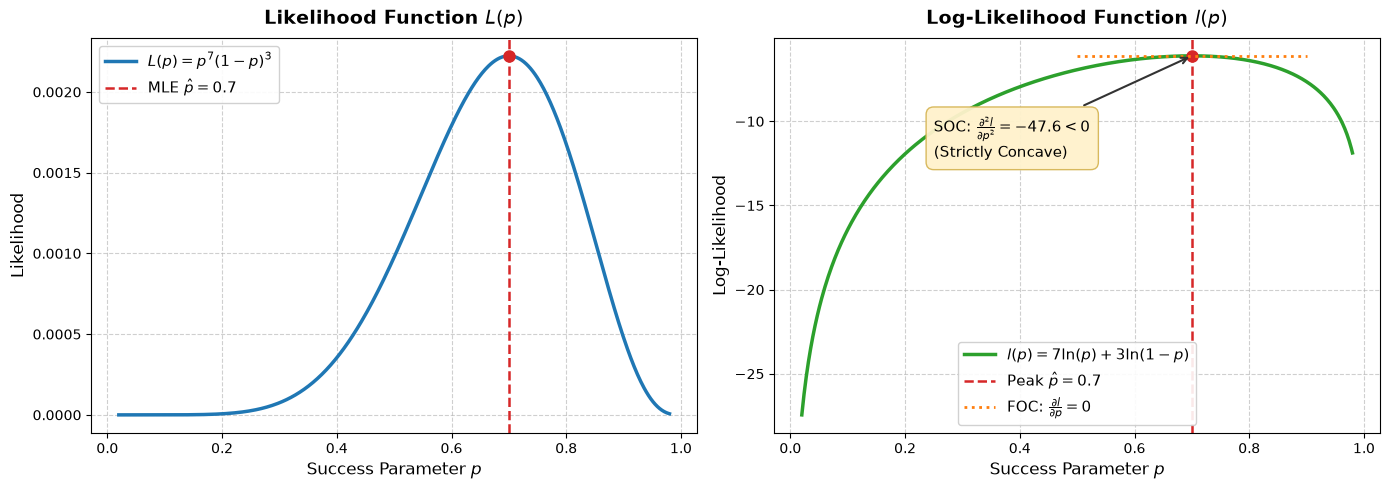

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set styling for clean, professional visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Concrete example: n = 10 trials, k = 7 successes
n = 10
k = 7
p_mle = k / n

# Parameter grid
p = np.linspace(0.02, 0.98, 500)

# Likelihood L(p) and Log-Likelihood l(p)
likelihood = (p ** k) * ((1 - p) ** (n - k))
log_likelihood = k * np.log(p) + (n - k) * np.log(1 - p)

# Plot 1: Likelihood Function
ax1.plot(p, likelihood, color='#1f77b4', lw=2.5, label=r'$L(p) = p^7 (1-p)^3$')
ax1.axvline(p_mle, color='#d62728', linestyle='--', lw=1.8, label=rf'MLE $\hat{{p}} = {p_mle}$')
ax1.plot(p_mle, (p_mle ** k) * ((1 - p_mle) ** (n - k)), 'o', color='#d62728', markersize=8)
ax1.set_title('Likelihood Function $L(p)$', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Success Parameter $p$', fontsize=12)
ax1.set_ylabel('Likelihood', fontsize=12)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Log-Likelihood Function with Tangent and Curvature
ax2.plot(p, log_likelihood, color='#2ca02c', lw=2.5, label=r'$l(p) = 7\ln(p) + 3\ln(1-p)$')
max_l = k * np.log(p_mle) + (n - k) * np.log(1 - p_mle)
ax2.axvline(p_mle, color='#d62728', linestyle='--', lw=1.8, label=rf'Peak $\hat{{p}} = {p_mle}$')
ax2.plot(p_mle, max_l, 'o', color='#d62728', markersize=8)

# Tangent line at peak (slope = 0)
p_tangent = np.linspace(p_mle - 0.2, p_mle + 0.2, 50)
ax2.plot(p_tangent, np.full_like(p_tangent, max_l), color='#ff7f0e', linestyle=':', lw=2, label=r'FOC: $\frac{\partial l}{\partial p} = 0$')

# Annotation for negative curvature
soc_val = -n / (p_mle * (1 - p_mle))
ax2.annotate(rf'SOC: $\frac{{\partial^2 l}}{{\partial p^2}} = {soc_val:.1f} < 0$' + '\n(Strictly Concave)',
             xy=(p_mle, max_l), xytext=(p_mle - 0.45, max_l - 6),
             arrowprops=dict(arrowstyle='->', color='#333333', lw=1.5),
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff2cc', edgecolor='#d6b656', alpha=0.95),
             fontsize=11)

ax2.set_title('Log-Likelihood Function $l(p)$', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Success Parameter $p$', fontsize=12)
ax2.set_ylabel('Log-Likelihood', fontsize=12)
ax2.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11, loc='lower center')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
